# EDA — Telco Customer Churn

Análise exploratória completa do dataset de churn de telecomunicações (Telco Customer Churn — IBM).

**Objetivo:** Entender volume, qualidade, distribuição e prontidão dos dados antes da modelagem.

## 0. Configuração inicial — Seed e bibliotecas

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

logger.info("Seed fixado: %d", SEED)

INFO - Seed fixado: 42


## 1. Carregamento dos dados

In [2]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")
logger.info("Dataset carregado: %d linhas, %d colunas", df.shape[0], df.shape[1])
df.head()

INFO - Dataset carregado: 7043 linhas, 33 colunas


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 2. Entendendo a estrutura — Volume, Tipos e Qualidade

In [3]:
logger.info("Shape: %s", df.shape)
print(df.dtypes)

INFO - Shape: (7043, 33)


CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object


## 3. Variável alvo — Distribuição de Churn

 **desbalanceamento de classes**: 26,5% de clientes cancelaram (churn = Yes).

INFO - Distribuição de Churn: {'No': 5174, 'Yes': 1869}


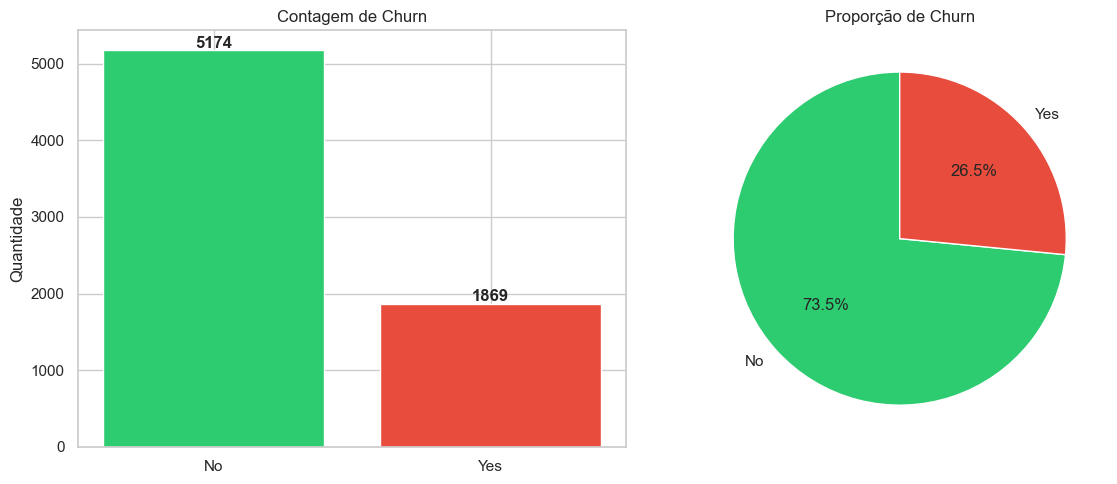

In [4]:
churn_counts = df["Churn Label"].value_counts()
churn_pct = df["Churn Label"].value_counts(normalize=True) * 100

logger.info("Distribuição de Churn: %s", churn_counts.to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(churn_counts.index, churn_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Contagem de Churn")
axes[0].set_ylabel("Quantidade")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[1].set_title("Proporção de Churn")

plt.tight_layout()
plt.show()

## 4. Qualidade dos dados — Nulos

In [5]:
nulls = df.isnull().sum()
nulls_nonzero = nulls[nulls > 0]
logger.info("Colunas com nulos: %s", nulls_nonzero.to_dict())
nulls

INFO - Colunas com nulos: {'Churn Reason': 5174}


CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

## 5. Tratamento de tipos — `Total Charges` como string

In [6]:
logger.info("Tipo original de 'Total Charges': %s", df["Total Charges"].dtype)
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
n_nulls = df["Total Charges"].isnull().sum()
logger.info("Nulos após conversão: %d — imputando com mediana", n_nulls)
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())
logger.info("Tipo final de 'Total Charges': %s", df["Total Charges"].dtype)

INFO - Tipo original de 'Total Charges': object
INFO - Nulos após conversão: 11 — imputando com mediana
INFO - Tipo final de 'Total Charges': float64


## 6. Análise das variáveis numéricas

### 6.1 Estatísticas descritivas

In [7]:
num_cols = ["Tenure Months", "Monthly Charges", "Total Charges"]
df[num_cols].describe()

,Tenure Months,Monthly Charges,Total Charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### 6.2 Distribuição das variáveis numéricas (histogramas)

- **Tenure Months**: muitos clientes novos (tenure ≈ 0) e muitos clientes antigos (tenure ≈ 70). Clientes com pouco tempo são mais propensos ao churn.
- **Monthly Charges**: distribuição quase uniforme com pico em cobranças baixas.
- **Total Charges**: concentrado em valores baixos.

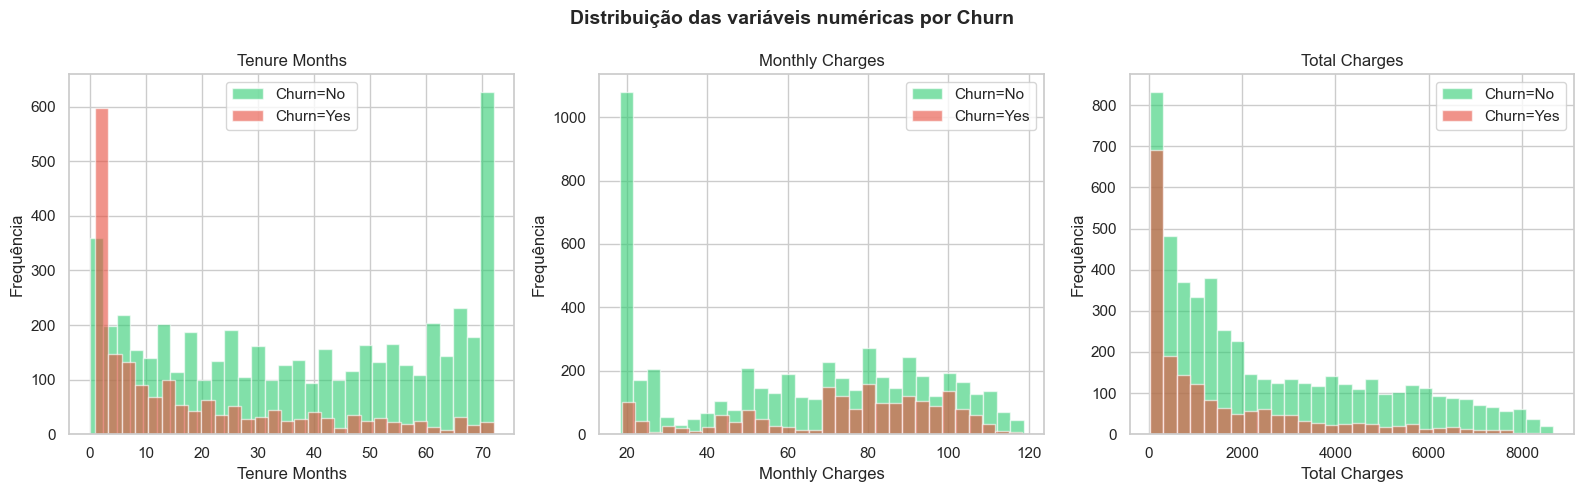

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    for label, color in [("No", "#2ecc71"), ("Yes", "#e74c3c")]:
        ax.hist(
            df[df["Churn Label"] == label][col],
            bins=30, alpha=0.6, label=f"Churn={label}", color=color
        )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
    ax.legend()

plt.suptitle("Distribuição das variáveis numéricas por Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.3 Boxplots por grupo de Churn

Clientes que cancelaram têm **menor tempo de contrato (tenure)** e **mensalidade mais alta**

C:\Users\mateus.nascimento\AppData\Local\Temp\ipykernel_9660\2920329418.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=["Não churnou", "Churnou"], patch_artist=True)
C:\Users\mateus.nascimento\AppData\Local\Temp\ipykernel_9660\2920329418.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=["Não churnou", "Churnou"], patch_artist=True)
C:\Users\mateus.nascimento\AppData\Local\Temp\ipykernel_9660\2920329418.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=["Não churnou", "Churnou"], patch_artist=True)


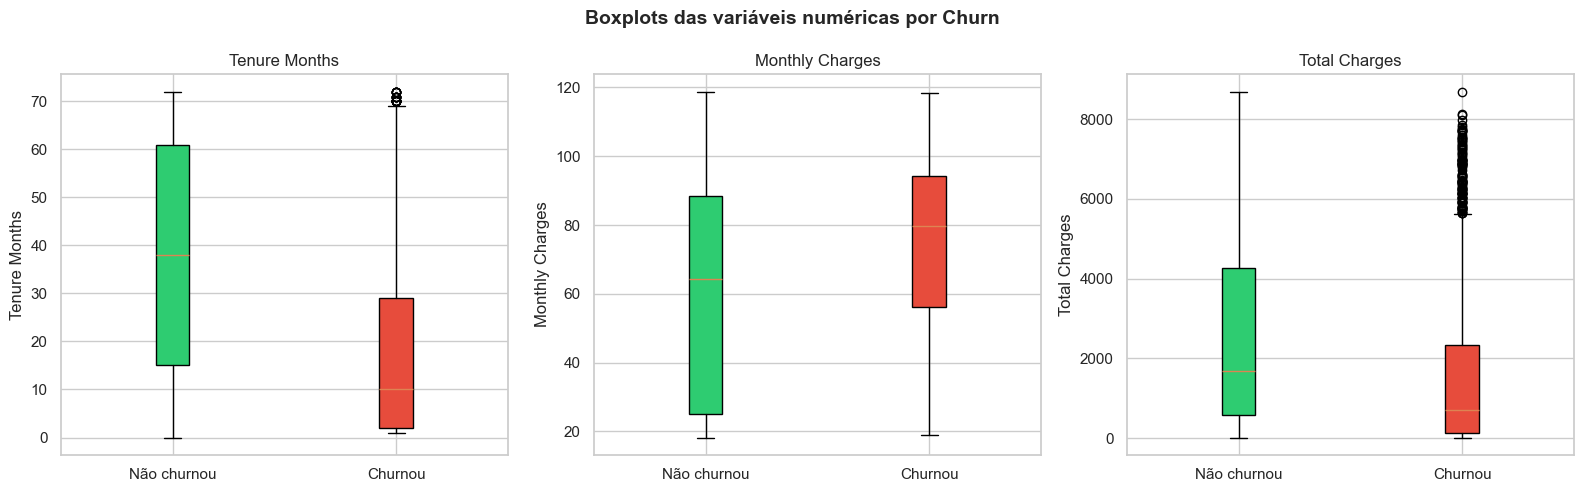

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    groups = [df[df["Churn Label"] == lbl][col].dropna() for lbl in ["No", "Yes"]]
    bp = ax.boxplot(groups, labels=["Não churnou", "Churnou"], patch_artist=True)
    bp["boxes"][0].set_facecolor("#2ecc71")
    bp["boxes"][1].set_facecolor("#e74c3c")
    ax.set_title(col)
    ax.set_ylabel(col)

plt.suptitle("Boxplots das variáveis numéricas por Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.4 Matriz de correlação

- **Tenure** tem correlação negativa com Churn (quanto mais tempo de contrato = menos churn).
- **Monthly Charges** tem correlação positiva com Churn (mensalidade mais alta = mais churn).
- **Total Charges** e **Tenure** têm alta correlação entre si ( Total = Tenure × Monthly).

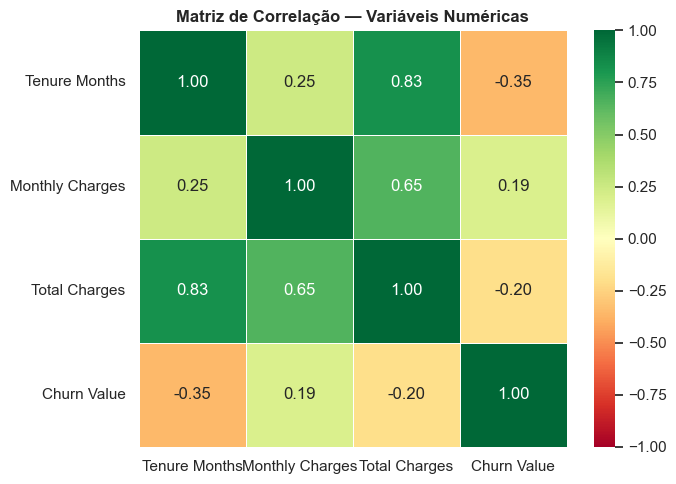

In [10]:
corr_df = df[["Tenure Months", "Monthly Charges", "Total Charges", "Churn Value"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlação — Variáveis Numéricas", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Análise das variáveis categóricas

Para cada variável categórica relevante, calculamos a **taxa de churn por categoria**.

In [11]:
def plot_churn_rate(col, ax, title=None):
    """Plota taxa de churn (%) por categoria de uma coluna."""
    churn_rate = (
        df.groupby(col)["Churn Value"].mean() * 100
    ).sort_values(ascending=False)
    colors = ["#e74c3c" if v > 30 else "#f39c12" if v > 15 else "#2ecc71"
              for v in churn_rate.values]
    bars = ax.bar(churn_rate.index, churn_rate.values, color=colors)
    ax.set_title(title or col, fontweight="bold")
    ax.set_ylabel("Taxa de Churn (%)")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", fontsize=9)
    ax.axhline(df["Churn Value"].mean() * 100, color="black",
               linestyle="--", linewidth=1, label="Média geral")
    ax.legend(fontsize=8)

### 7.1 Dados demográficos (Gender, Senior Citizen, Partner, Dependents)

**Insights:**
- **Gênero** não influencia significativamente o churn.
- **Senior Citizens** têm taxa de churn 41% vs. 23% dos não-seniors.
- Clientes **sem parceiro** e **sem dependentes** cancelam mais.

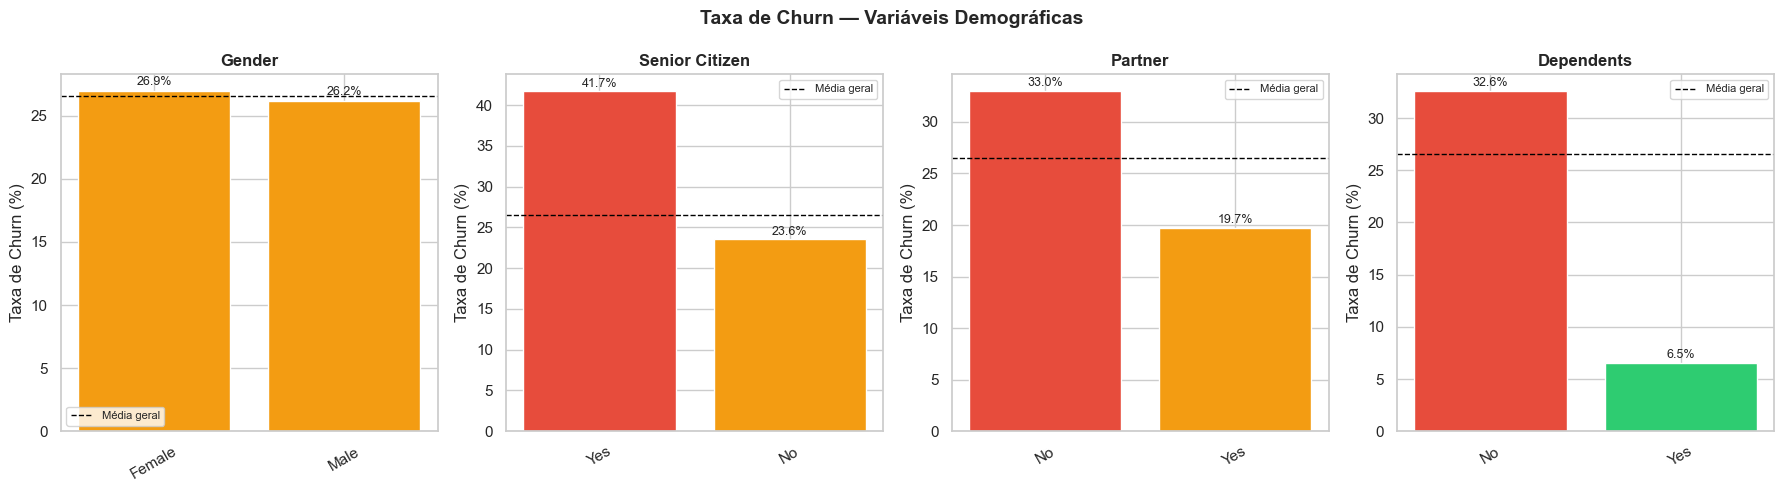

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, ["Gender", "Senior Citizen", "Partner", "Dependents"]):
    plot_churn_rate(col, ax)
plt.suptitle("Taxa de Churn — Variáveis Demográficas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 7.2 Serviços de telefone (Phone Service, Multiple Lines)

**Insights:**
- Clientes com ou sem serviço de múltiplas linhas têm taxas de churn similares.
- A presença de **Phone Service** sozinha não diferencia muito.

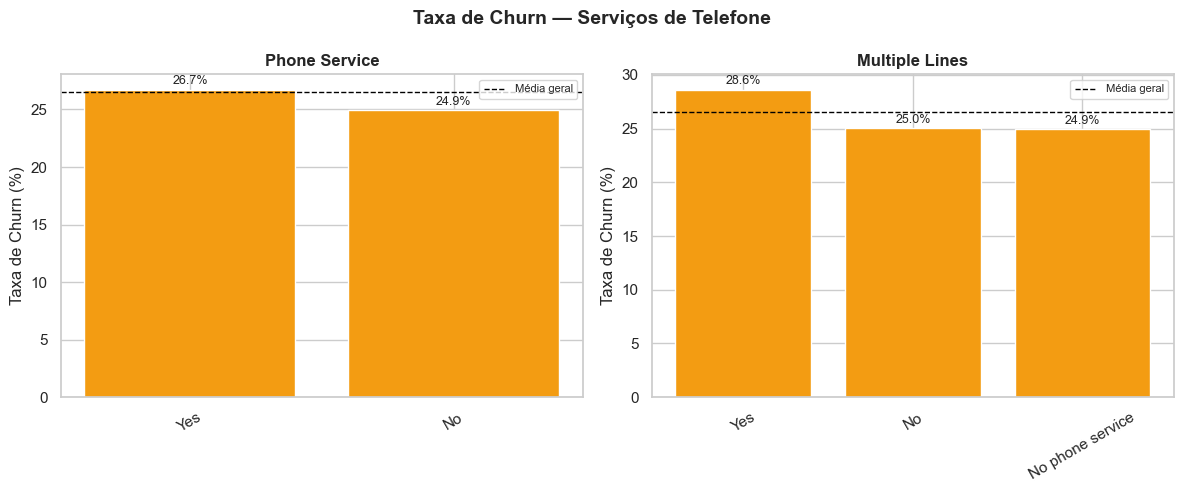

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ["Phone Service", "Multiple Lines"]):
    plot_churn_rate(col, ax)
plt.suptitle("Taxa de Churn — Serviços de Telefone", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 7.3 Serviços de internet e adicionais

**Insights:**
- **Fiber optic** tem taxa de churn altíssima (41%).
- Clientes **sem segurança online** e **sem suporte técnico** cancelam bem mais.
- **Online Backup** e **Device Protection** seguem padrão similar.

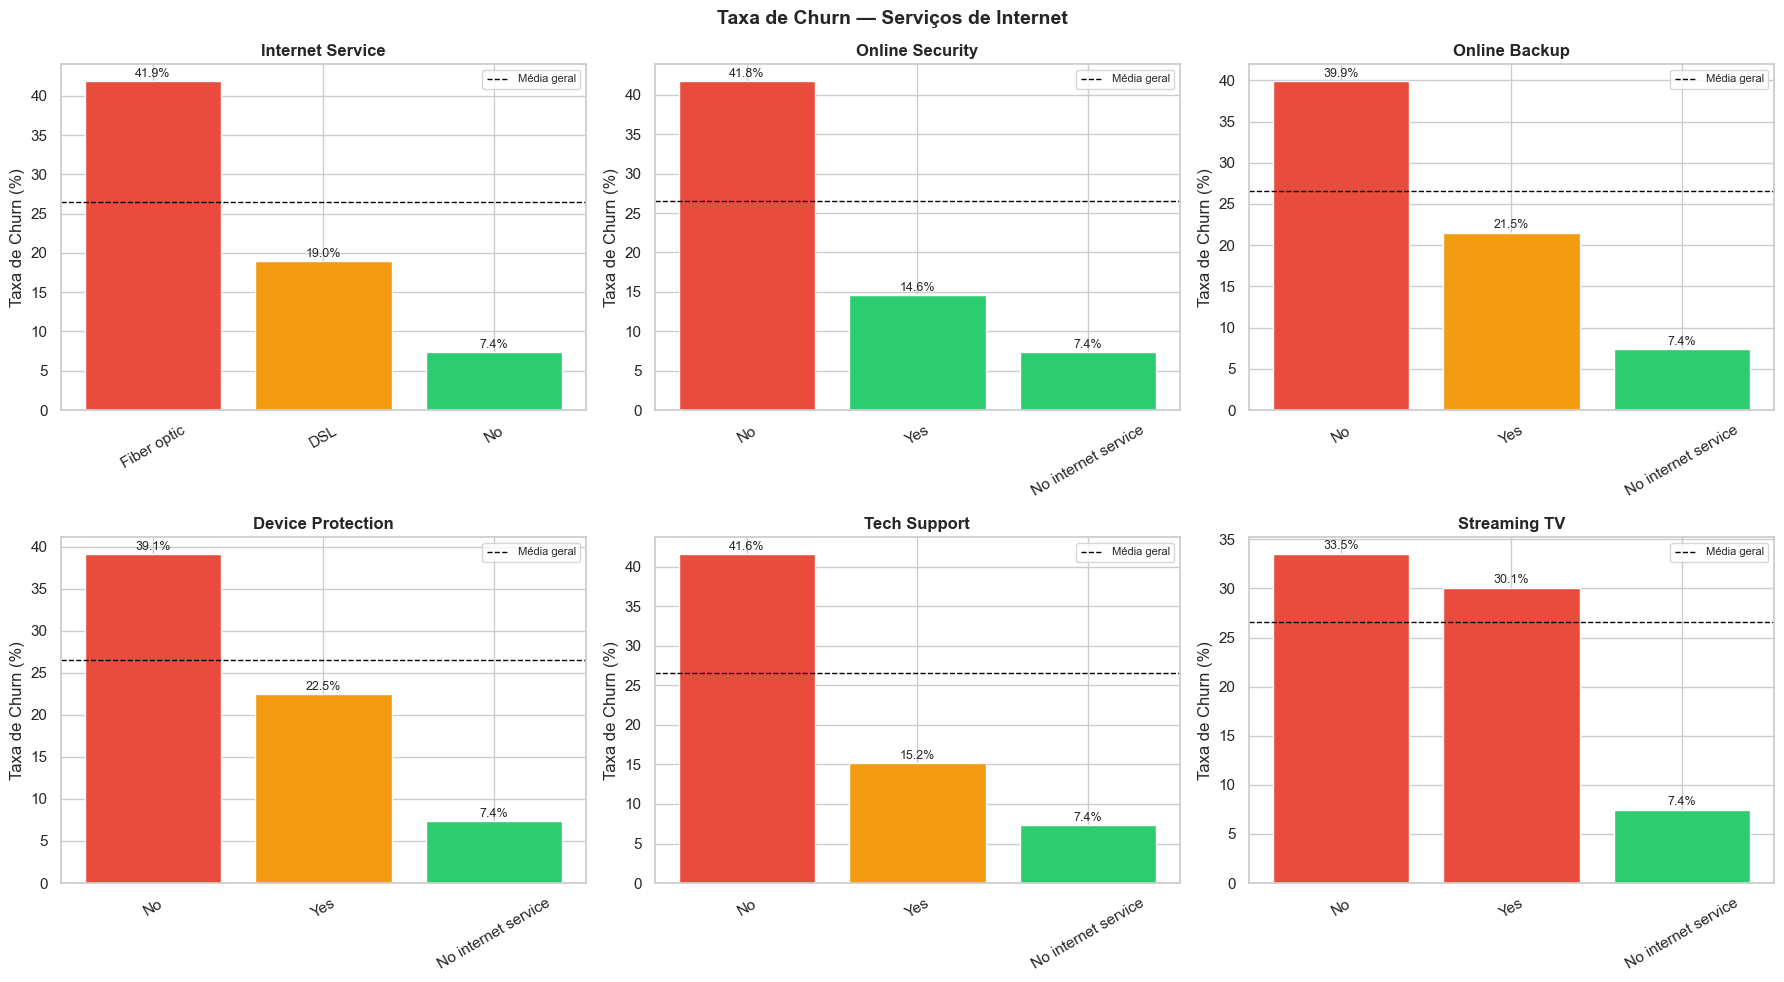

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
internet_cols = [
    "Internet Service", "Online Security", "Online Backup",
    "Device Protection", "Tech Support", "Streaming TV"
]
for ax, col in zip(axes.flatten(), internet_cols):
    plot_churn_rate(col, ax)
plt.suptitle("Taxa de Churn — Serviços de Internet", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 7.4 Contrato, cobrança e pagamento

**Insights — variáveis mais importantes do dataset:**
- **Contrato mensal (Month-to-month)**: taxa de churn de 42%.
  Contratos anuais e bianuais têm taxas de 11% e 3% respectivamente.
- **Electronic check**: taxa de churn 45%.
- **Paperless Billing**: clientes com fatura digital cancelam mais (33% vs 16%).

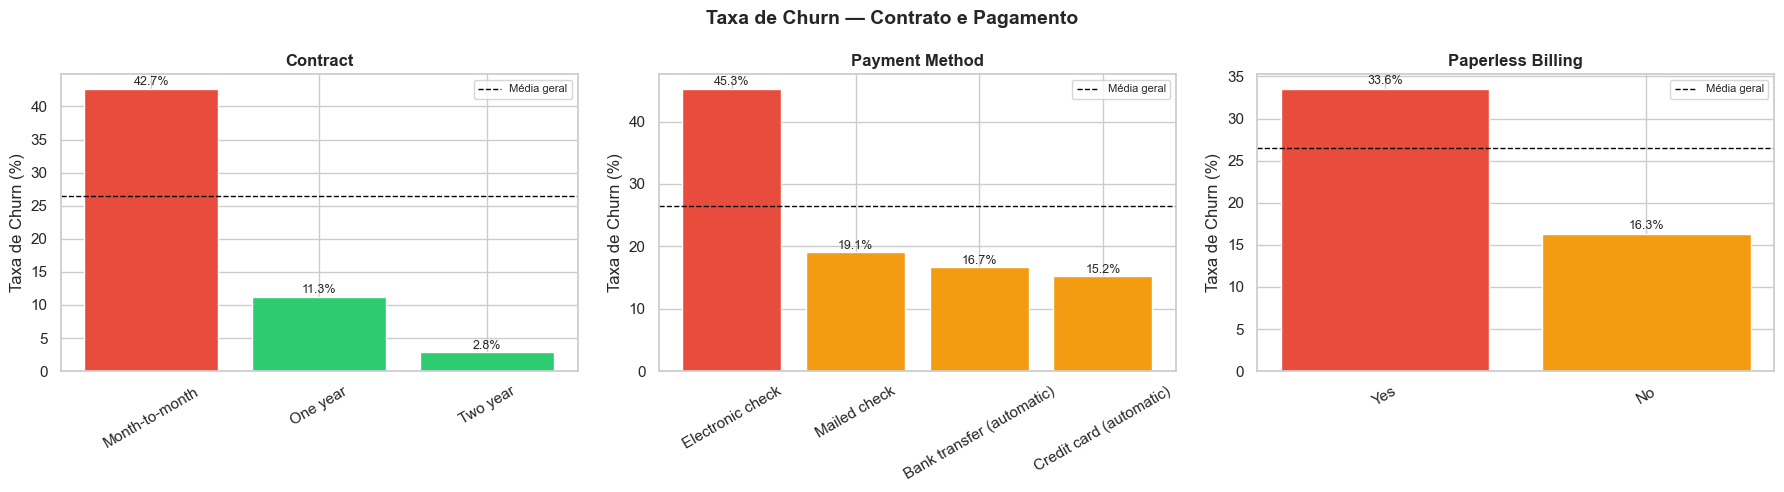

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Contract", "Payment Method", "Paperless Billing"]):
    plot_churn_rate(col, ax)
plt.suptitle("Taxa de Churn — Contrato e Pagamento", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 7.5 Streaming TV e Streaming Movies

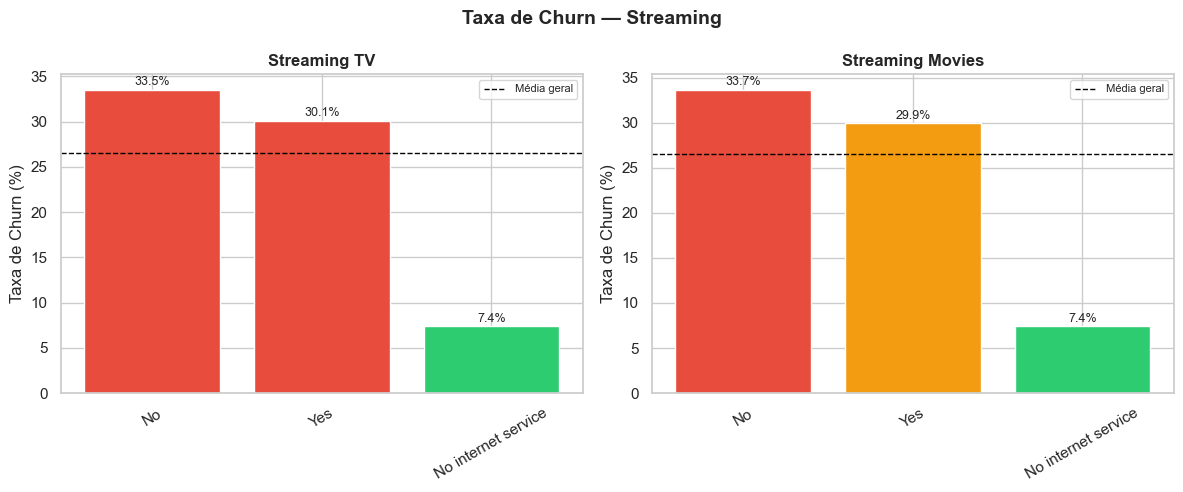

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ["Streaming TV", "Streaming Movies"]):
    plot_churn_rate(col, ax)
plt.suptitle("Taxa de Churn — Streaming", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Salvando DataFrame tratado

In [17]:
df.to_csv("../data/telco_churn_clean.csv", index=False)
logger.info("DataFrame tratado salvo em ../data/telco_churn_clean.csv")

INFO - DataFrame tratado salvo em ../data/telco_churn_clean.csv
